In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import phik

In [15]:
# load the data
df = pd.read_csv("../../../Datasets/adult.csv")


# let's quickly see the first 5 rows of data
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [16]:
df = df.drop_duplicates()

In [17]:
df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)

In [18]:
df.shape

(30139, 15)

##### <b> <u>Step 3a</u>: Major trends</b> 

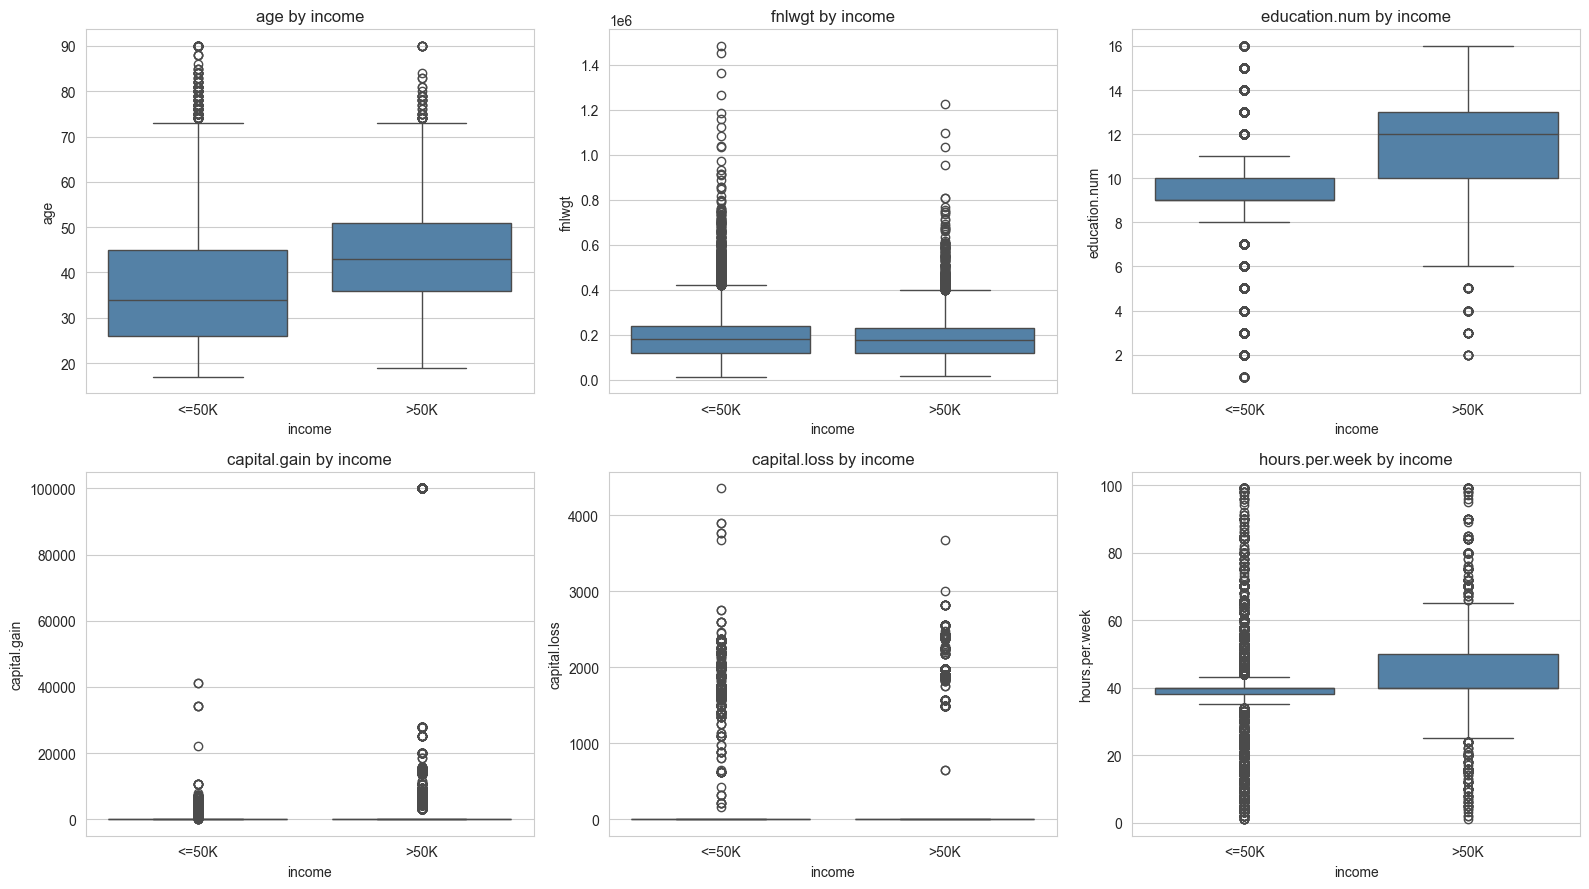

In [19]:
# Visualize the distribution of numeric features by income category
numeric_cols = ['age','fnlwgt','education.num','capital.gain','capital.loss','hours.per.week']

sns.set_style('whitegrid')
fig, axes = plt.subplots(2,3, figsize=(16,9))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='income', y=col, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} by income')
plt.tight_layout()
plt.show()
plt.close()

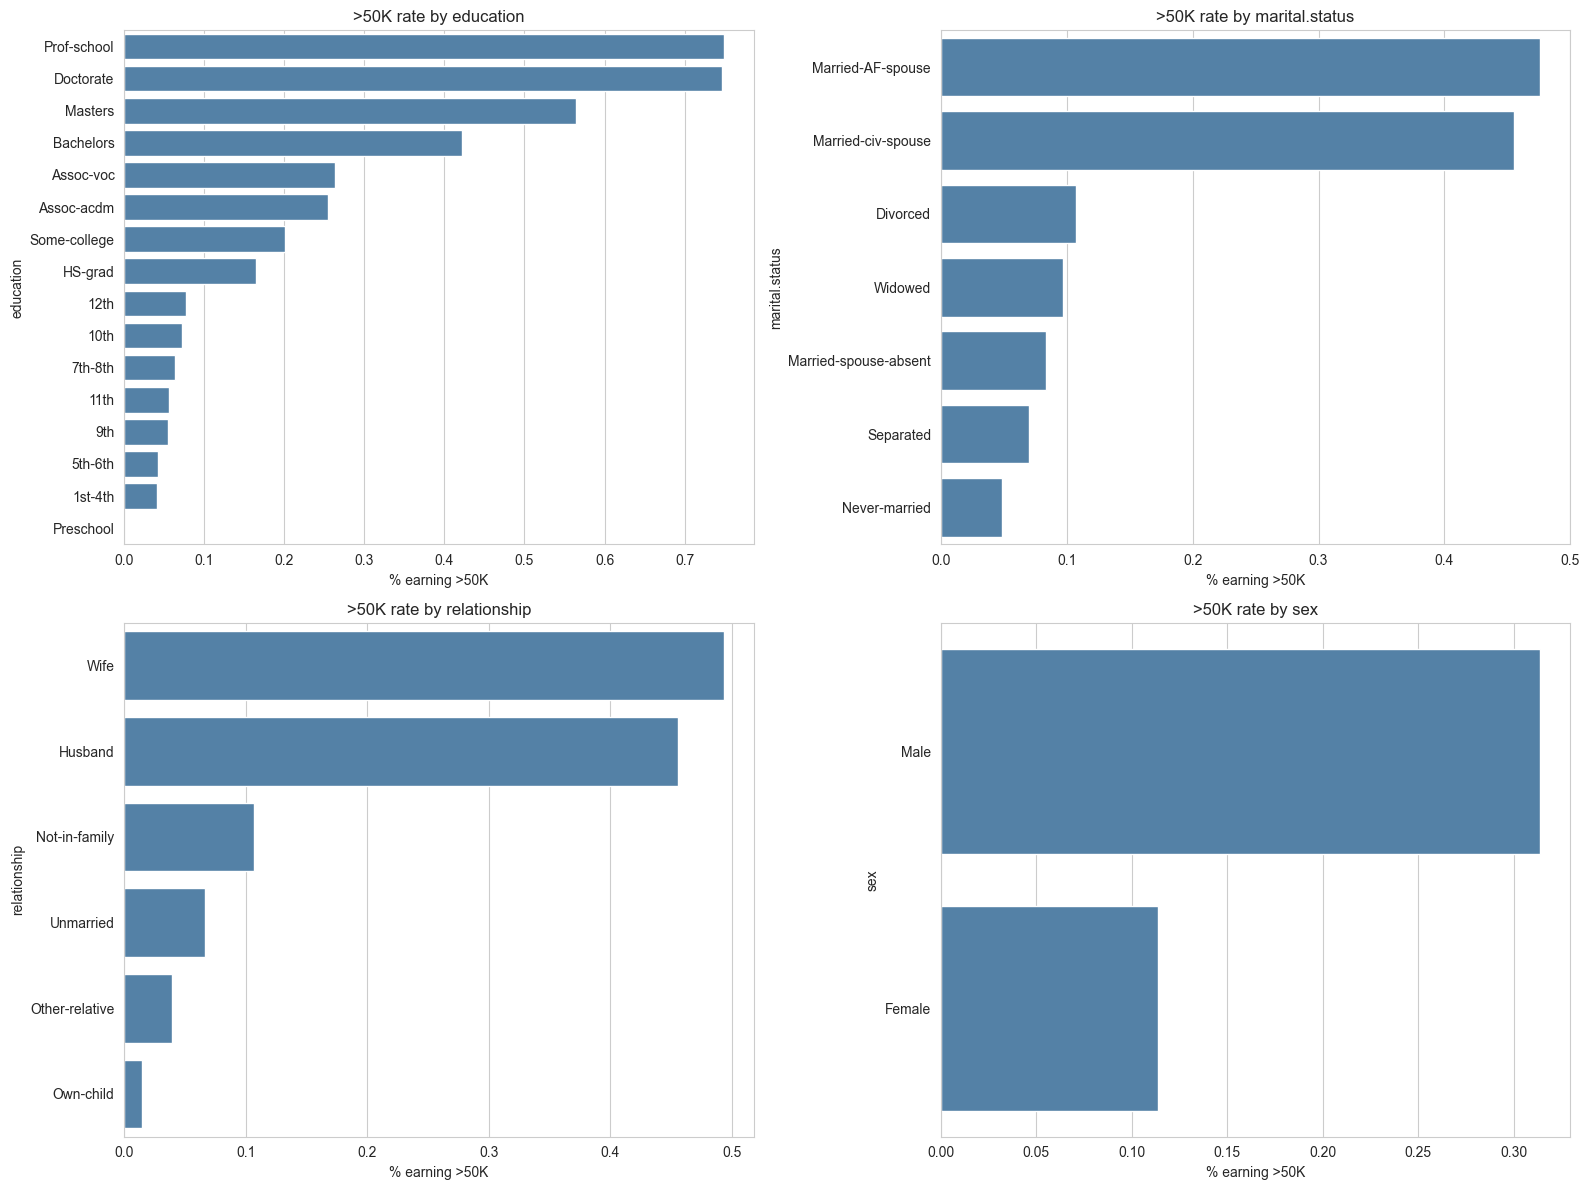

In [20]:
# Inspect the relationship between categorical features and income
df['income_binary'] = (df['income'] == '>50K').astype(int)

cat_cols = ['education','marital.status','relationship','sex']

fig, axes = plt.subplots(2,2, figsize=(16,12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['income_binary'].mean().sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index, ax=axes[i], color='steelblue')
    axes[i].set_xlabel('% earning >50K')
    axes[i].set_title(f'>50K rate by {col}')
plt.tight_layout()
plt.show()
plt.close()

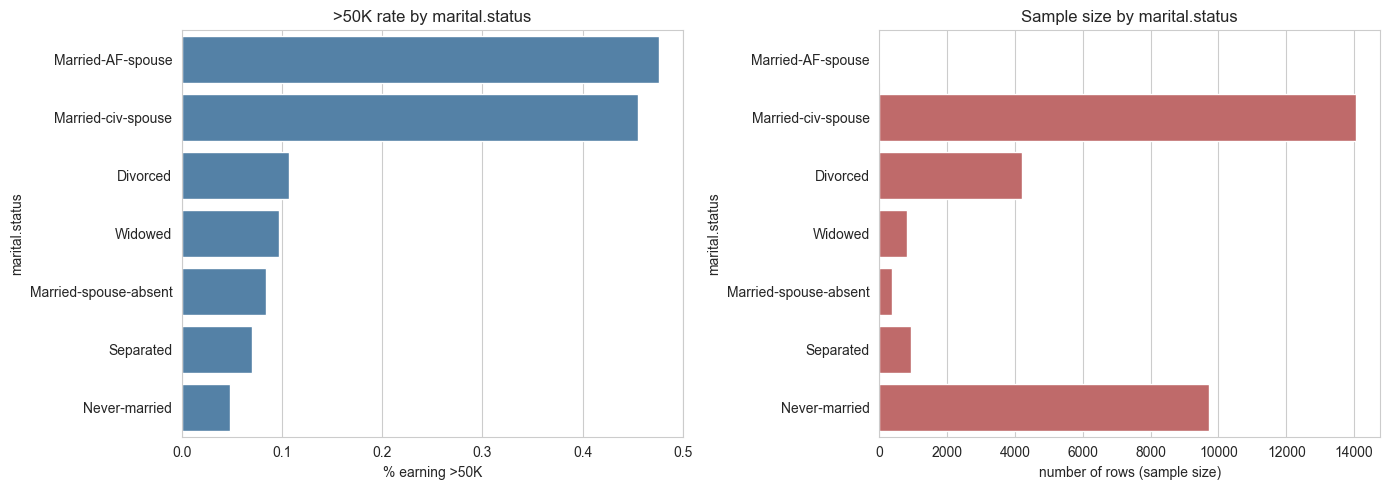

In [21]:
df['income_binary'] = (df['income'] == '>50K').astype(int)
summary = df.groupby('marital.status').agg(
    rate=('income_binary', 'mean'),
    n=('income_binary', 'count')
).sort_values('rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=summary['rate'].values, y=summary.index, ax=axes[0], color='steelblue')
axes[0].set_xlabel('% earning >50K')
axes[0].set_title('>50K rate by marital.status')

sns.barplot(x=summary['n'].values, y=summary.index, ax=axes[1], color='indianred')
axes[1].set_xlabel('number of rows (sample size)')
axes[1].set_title('Sample size by marital.status')

plt.tight_layout()
plt.show()

##### <b> <u>Step 3b</u>: Overlapping Data</b> 

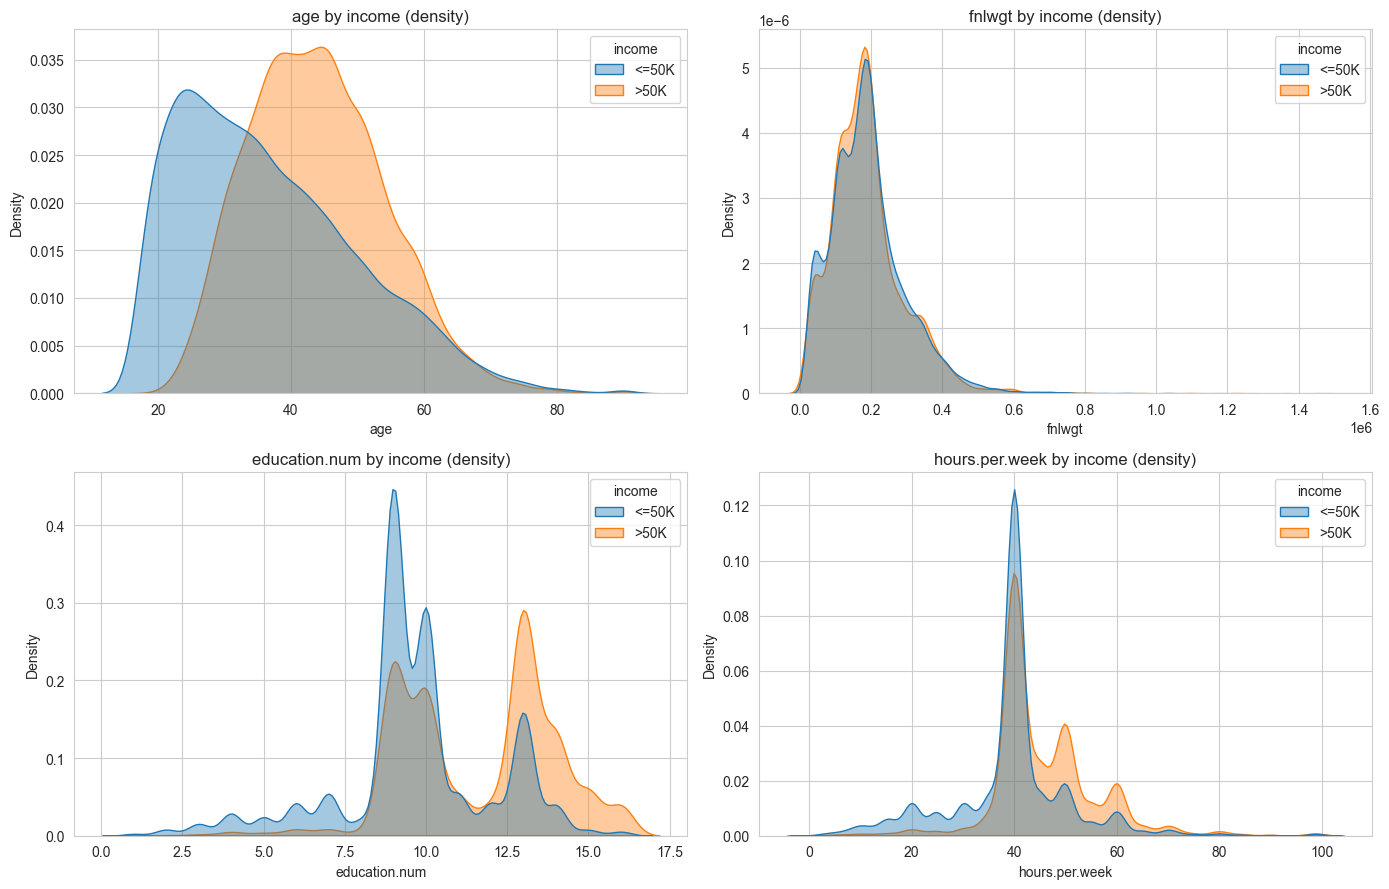

age              0.68
fnlwgt           0.95
education.num    0.67
hours.per.week   0.74


In [22]:
num = ['age', 'fnlwgt', 'education.num', 'hours.per.week']

# overlaid densities by income class
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, c in zip(axes.flatten(), num):
    sns.kdeplot(data=df, x=c, hue='income', common_norm=False, fill=True, alpha=0.4, ax=ax)
    ax.set_title(f'{c} by income (density)')
plt.tight_layout()
plt.show()

# overlap coefficient: 1 = identical distributions, 0 = fully separable
lo, hi = df[df.income == '<=50K'], df[df.income == '>50K']
for c in num:
    bins = np.histogram_bin_edges(df[c], bins=30)
    a, _ = np.histogram(lo[c], bins=bins)
    b, _ = np.histogram(hi[c], bins=bins)
    print(f'{c:16s} {np.minimum(a / a.sum(), b / b.sum()).sum():.2f}')

##### <b> <u>Step 3c</u>: Outliers & noise</b> 

In [24]:
num_cols = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
cat_cols = ['workclass', 'education', 'marital.status', 'occupation',
            'relationship', 'race', 'sex', 'native.country', 'income']

In [25]:
num_cols = ['age','fnlwgt','education.num','capital.gain','capital.loss','hours.per.week']

rows = []
for c in num_cols:
    s = df[c]
    median = s.median()
    mad = np.median(np.abs(s - median))
    n = (np.abs(s - median) > 3 * mad).sum()
    rows.append((c, median, mad, n, round(100 * n / len(df), 1)))
print(pd.DataFrame(rows, columns=['column', 'median', 'MAD', 'flagged', 'pct']))

# capital.gain / capital.loss again on non-zero rows only
for c in ['capital.gain', 'capital.loss']:
    s = df.loc[df[c] > 0, c]
    median = s.median()
    mad = np.median(np.abs(s - median))
    print(c, '(non-zero only): n =', len(s), '| MAD =', mad,
          '| flagged =', (np.abs(s - median) > 3 * mad).sum())

           column    median      MAD  flagged   pct
0             age      37.0     10.0      617   2.0
1          fnlwgt  178417.0  60231.0     1962   6.5
2   education.num      10.0      1.0     4854  16.1
3    capital.gain       0.0      0.0     2538   8.4
4    capital.loss       0.0      0.0     1427   4.7
5  hours.per.week      40.0      3.0    10568  35.1
capital.gain (non-zero only): n = 2538 | MAD = 3973.0 | flagged = 232
capital.loss (non-zero only): n = 1427 | MAD = 146.0 | flagged = 219


In [26]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
y_pred = iso.fit_predict(df[num_cols])
df['outlier'] = y_pred == -1

print('Outliers:', df['outlier'].sum(), '| Inliers:', (~df['outlier']).sum())
print('>50K rate  outliers:', round((df[df.outlier].income == '>50K').mean(), 3),
      '| inliers:', round((df[~df.outlier].income == '>50K').mean(), 3))
print(df.groupby('outlier')[num_cols].median())

Outliers: 1507 | Inliers: 28632
>50K rate  outliers: 0.597 | inliers: 0.231
          age    fnlwgt  education.num  capital.gain  capital.loss  \
outlier                                                              
False    37.0  178564.0           10.0           0.0           0.0   
True     47.0  175070.0           11.0           0.0        1668.0   

         hours.per.week  
outlier                  
False              40.0  
True               40.0  


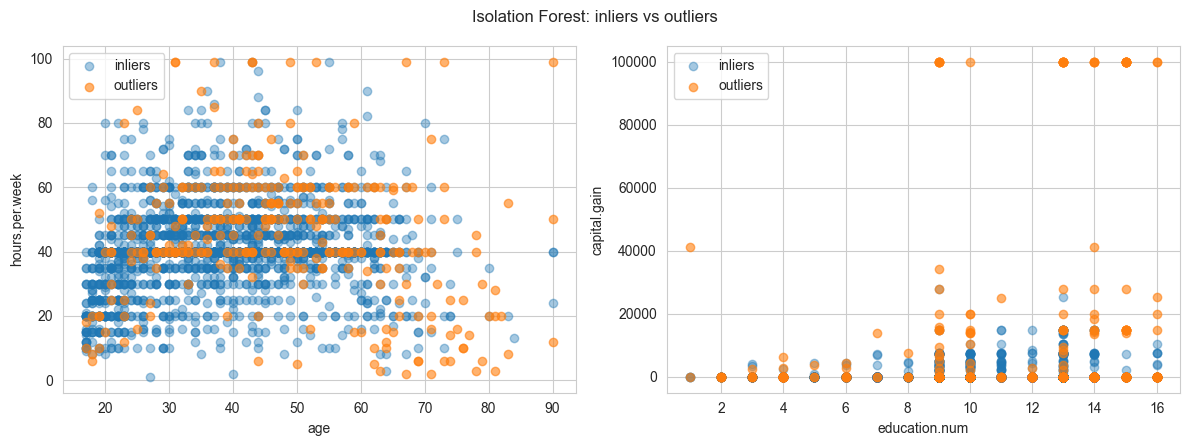

In [27]:
inl = df[~df.outlier].sample(3000, random_state=1)
out = df[df.outlier].sample(300, random_state=1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for a, (x, y) in zip(ax, [('age', 'hours.per.week'), ('education.num', 'capital.gain')]):
    a.scatter(inl[x], inl[y], alpha=0.4, label='inliers')
    a.scatter(out[x], out[y], alpha=0.6, label='outliers')
    a.set_xlabel(x); a.set_ylabel(y); a.legend()
plt.suptitle('Isolation Forest: inliers vs outliers')
plt.tight_layout(); plt.show()

##### <b> <u>Step 3d</u>: Correlations & associations</b> 


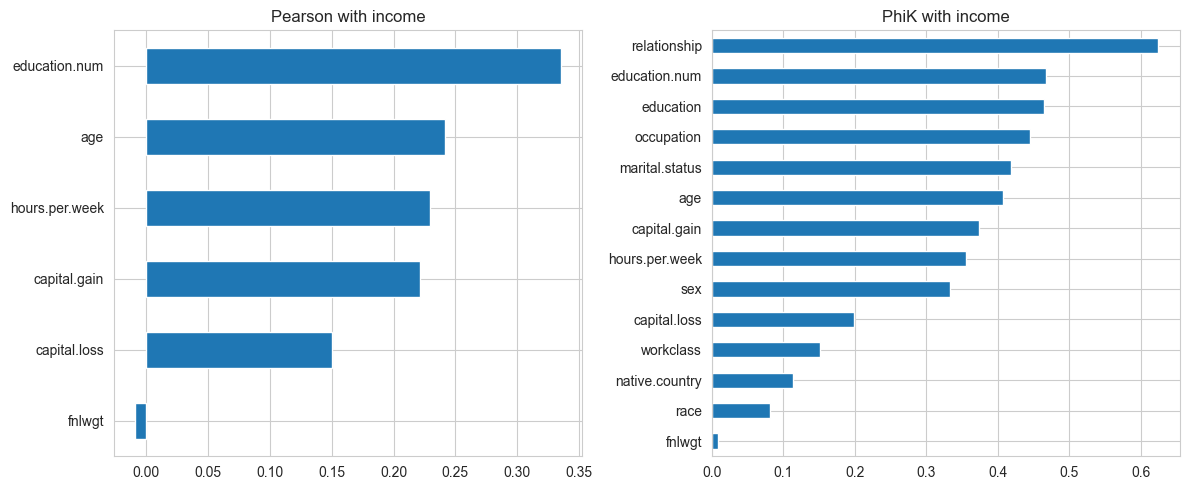

In [28]:
pear = df[num_cols + ['income_binary']].corr()['income_binary'].drop('income_binary')
cols = num_cols + ['workclass','education','marital.status','occupation',
                   'relationship','race','sex','native.country','income']
phik_t = df[cols].phik_matrix(interval_cols=num_cols)['income'].drop('income')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
pear.sort_values().plot.barh(ax=ax[0], title='Pearson with income')
phik_t.sort_values().plot.barh(ax=ax[1], title='PhiK with income')
plt.tight_layout(); plt.show()

In [32]:
print('PhiK with income:\n', phik_t.sort_values(ascending=False).round(3))

PhiK with income:
 relationship      0.624
education.num     0.468
education         0.465
occupation        0.445
marital.status    0.418
age               0.408
capital.gain      0.374
hours.per.week    0.355
sex               0.334
capital.loss      0.199
workclass         0.152
native.country    0.114
race              0.082
fnlwgt            0.008
Name: income, dtype: float64


Note: I asked AI to generate me the specific code so that I can have the result in the same cell, cross-checked with prof's code.

In [33]:
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, RFE
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

y = (df.income == '>50K').astype(int)
num_cols = ['age','fnlwgt','education.num','capital.gain','capital.loss','hours.per.week']
cat_cols = ['workclass','marital.status','occupation','relationship','race','sex','native.country']
X = df[num_cols + cat_cols]          # education left out (duplicate of education.num)

# 1) Mutual information
Xo = X.copy(); Xo[cat_cols] = OrdinalEncoder().fit_transform(X[cat_cols])
mask = [c in cat_cols for c in Xo.columns]
mi = pd.Series(mutual_info_classif(Xo, y, discrete_features=mask, random_state=42),
               index=Xo.columns).sort_values(ascending=False)
print('Mutual Information with income:\n', mi.round(3))
print('\n')

# 2) chi2 (one-hot + min-max scaling, then best score per original column)
Xd = pd.get_dummies(X, columns=cat_cols)
Xd_s = pd.DataFrame(MinMaxScaler().fit_transform(Xd), columns=Xd.columns)
chi = pd.Series(SelectKBest(chi2, k='all').fit(Xd_s, y).scores_, index=Xd.columns)
parent = lambda c: next((p for p in cat_cols if c.startswith(p + '_')), c)
print('Chi2 with income:\n', chi.groupby(parent).max().sort_values(ascending=False).round(0))
print('\n')

# 3) RFE with logistic regression
Xr = pd.DataFrame(StandardScaler().fit_transform(Xd), columns=Xd.columns)
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=10).fit(Xr, y)
rk = pd.Series(rfe.ranking_, index=Xd.columns)
print('RFE with income:\n', rk.groupby(parent).min().sort_values())

Mutual Information with income:
 relationship      0.115
marital.status    0.109
capital.gain      0.083
education.num     0.067
age               0.066
occupation        0.065
hours.per.week    0.042
capital.loss      0.034
fnlwgt            0.030
sex               0.026
workclass         0.012
native.country    0.006
race              0.006
dtype: float64


Chi2 with income:
 marital.status    3189.0
relationship      2845.0
occupation        1192.0
sex                956.0
capital.gain       741.0
workclass          550.0
capital.loss       288.0
race               213.0
age                194.0
education.num      161.0
native.country     123.0
hours.per.week      58.0
fnlwgt               0.0
dtype: float64


RFE with income:
 age                1
capital.gain       1
education.num      1
hours.per.week     1
marital.status     1
sex                1
relationship       1
occupation         1
capital.loss       5
native.country    11
workclass         12
fnlwgt            25
race   